Aim
=====

The aim of this session is to use decision trees, which are famous ML models for precision medicine problems due to their high interpretability. We are going to use a publicly available dataset, the heart failure prediction dataset that can be found [here](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction).

Please note that I will not perform exploratory data analysis as this is not the focus.

Dataset:
========
The dataset contains data from 918 individuals and was created with the aim of identifying people who have cardiovascular disease (CVD) or are at risk of developing CVD. In total, 11 features are available:

1. Age: age of the patient [years]
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, 4. NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results – measures the electrical activity of the heart [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
Additionally the column HeartDisease provides the output class [1: heart disease, 0: Normal]

The dataset was adopted from: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Author: Polyxeni Gkontra, Machine Learning for Precision Medicine, MBDS, 2024

Data Preparation
============

Import the required libraries

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import io
# Libraries related to classification
from sklearn.metrics import classification_report, roc_curve, ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler

Load the file.

Read the .csv file with the patient information. Then create a dataframe X that contains only the features and another one that contains the labels. Useful: [read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) function from pandas

In [2]:
# Read the csv file
data = pd.read_csv("heart.csv")

In [3]:
# Column name that contains the class information
label = 'HeartDisease'
# Dataframe with the labels
Y =pd.DataFrame(columns=[label])
Y[label] = data[label].copy()
# Drop the column with the classes from the X data so as to create a dataframe containing only features
X = data.drop(label, axis=1)

Print the number of patients in each class and create a relevant plot. Useful: [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html)

410
508


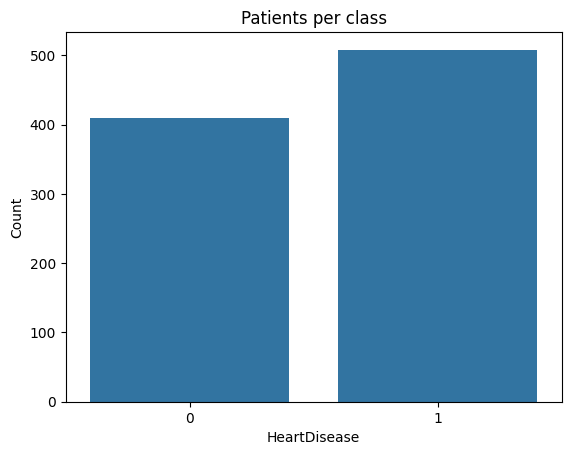

In [4]:
# The number of individuals in each class
print((Y['HeartDisease'] == 0).sum())
print((Y['HeartDisease'] == 1).sum())

# Create a countplot with the number of patients per category
sns.countplot(x=Y[label].values)
plt.xlabel(label)
plt.ylabel("Count")
plt.title("Patients per class")
plt.show()

Check for missing values (Helpful: Function [isnull](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.isnull.html) from [pandas](https://pandas.pydata.org/docs/))

In [5]:
#check missing values
data.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Basic statistics (Helpful: Methods [describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html), [info](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) from pandas)

In [6]:
print(data.describe())
print(data.info())


              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Da

Split the dataset into training (80%) and testing (20%). We will leave the testing set aside and further split the training into training and validation. Useful: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

X_train.info()


<class 'pandas.DataFrame'>
Index: 734 entries, 761 to 175
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    str    
 2   ChestPainType   734 non-null    str    
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    str    
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    str    
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    str    
dtypes: float64(1), int64(5), str(5)
memory usage: 68.8 KB


Check first rows of X_train

In [8]:
X_train.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
761,52,M,ASY,112,230,0,Normal,160,N,0.0,Up
470,53,M,ASY,126,0,0,Normal,106,N,0.0,Flat
138,54,M,ASY,140,166,0,Normal,118,Y,0.0,Flat
54,52,F,ASY,130,180,0,Normal,140,Y,1.5,Flat
435,60,M,ASY,152,0,0,ST,118,Y,0.0,Up


Transform categorical variables using one hot-key encoding for sex and ordinal encoding for the rest

In [9]:
# Check the type of the features
X_train.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
dtype: object

Get the categorical features and their indexes as well as the index of the sex attribute to treat it differently during encoding.

In [10]:
# Numerical features
num_features = list(X_train.select_dtypes(include=["int64", "float64"]).columns)
# Indices of numerical features
numerical_idx = [loc for loc, key in enumerate(X_train.columns) if key in num_features]
# Indices of columns with categorical data
categorical_idx = list(set(range(0,X_train.shape[1])) - set(numerical_idx))
# Index of sex attribute
sex_idx = [loc for loc, key in enumerate(X_train.columns) if key == 'Sex']
# Delete sex from the indices of categorical features
categorical_idx.remove(sex_idx[0])
# Names of categorical features
cat_features = X_train.columns[categorical_idx]
# Print all features
print("All available features: ", X_train.columns)
# Print numerical features
print("Numerical features: ", num_features)
# Print categorical features
print("Categorical features: ", cat_features)

All available features:  Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='str')
Numerical features:  ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical features:  Index(['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


Encode the sex attribute by means of one-hot key encoding and the rest using ordinal encoding. Useful: [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn-preprocessing-ordinalencoder)

In [11]:
# Function to help with one hot key encoding with pandas. Reproduced from
# https://stackoverflow.com/questions/37292872/how-can-i-one-hot-encode-in-python
def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]])
    res = pd.concat([original_dataframe, dummies], axis=1)
    res = res.drop([feature_to_encode], axis=1)
    return(res)

In [12]:
# importing copy module
import copy

# Create copies of the features
X_train_enc = copy.deepcopy(X_train)
X_test_enc = copy.deepcopy(X_test)

# Get one hot key encoding for sex attribute
X_train_enc = encode_and_bind(X_train_enc, 'Sex')
X_test_enc = encode_and_bind(X_test_enc, 'Sex')

# Handle all other categorical variables using ordinal encoder
# cat_features was defined earlier (categorical columns except Sex)
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc[cat_features] = ordinal_encoder.fit_transform(X_train_enc[cat_features])
X_test_enc[cat_features] = ordinal_encoder.transform(X_test_enc[cat_features])

# Apply normalization to numerical variables
num_preprocessor = MinMaxScaler()
X_train_enc[num_features] = num_preprocessor.fit_transform(X_train_enc[num_features])
X_test_enc[num_features] = num_preprocessor.transform(X_test_enc[num_features])


In [13]:
# Name of the columns
X_train_enc.columns

Index(['Age', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Sex_F',
       'Sex_M'],
      dtype='str')

Transfrom the labels using the [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)

In [14]:
# Define transform for the target labels - attention! LabelEncoder is for target variables only!
le = LabelEncoder()
# Transform the training data with LabelEncoder
Y_train_enc = le.fit_transform(y_train)
# Transform the testing data
Y_test_enc = le.transform(y_test)

/Users/johannaalbers/Documents/Uni/URV/second_semester/ML/ML_venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/johannaalbers/Documents/Uni/URV/second_semester/ML/ML_venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Decision trees
=====
Decision trees are considered ¨white box¨ models allowing to completely understand how a decision was made by the algorithm. Here, we are going to use them to predict whether a patient has or is at risk of heart disease.

Train a decision tree model and apply it to the testing data. Evaluate the performance of the model in terms of precision, recall, f1 score and roc auc. Moreover, calculate and visualize the confusion matrix. Useful: [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn-tree-decisiontreeclassifier), [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html), [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

In [15]:
from sklearn import tree

0.8315217391304348


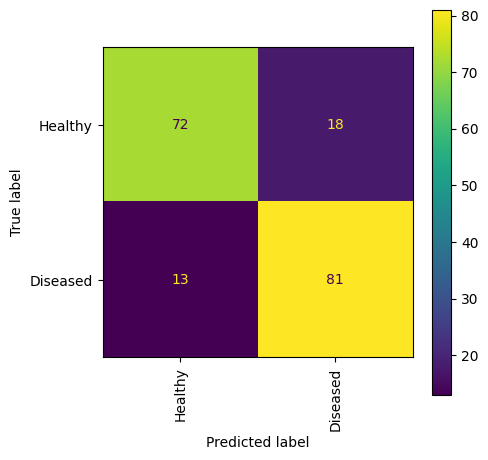

In [16]:
# Define the decision tree model to be used
tree_model = tree.DecisionTreeClassifier(criterion="entropy", max_depth=2)

# Fit the model to the training data
tree_model = tree_model.fit(X_train_enc, Y_train_enc)

# Apply the trained model to the testing data
Y_tree1 = tree_model.predict(X_test_enc)

# Evaluate the performance of the model
print(tree_model.score(X_test_enc, Y_test_enc))

# Calculate confusion matrix
cm_tree1 = confusion_matrix(Y_test_enc, Y_tree1)
# Plot the confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix=cm_tree1, display_labels = ['Healthy', 'Diseased'])
fig, ax = plt.subplots(figsize=(5,5))
display.plot(ax=ax, xticks_rotation='vertical')
plt.show()

Let's now make a change. Let's change the balanced weight and other parameters (max_depth, min_samples_split, min_samples_leaf
, max_features)

0.8478260869565217


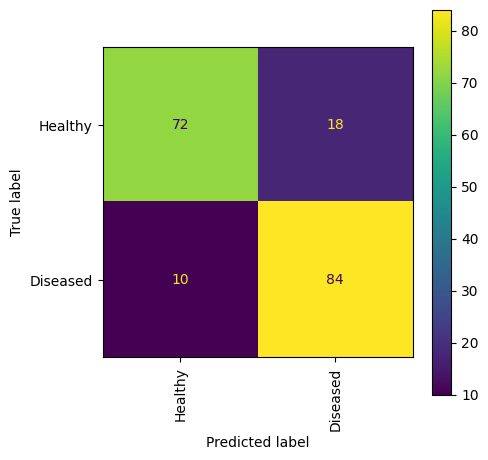

In [23]:
tree_model_balanced = tree.DecisionTreeClassifier(criterion="entropy", max_depth=4, class_weight="balanced")        #Pays more attention to the minority class

# Fit the model to the training data
tree_model_balanced = tree_model_balanced.fit(X_train_enc, Y_train_enc)

# Apply the trained model to the testing data
Y_tree1_balanced = tree_model_balanced.predict(X_test_enc)

# Evaluate the performance of the model
print(tree_model_balanced.score(X_test_enc, Y_test_enc))

# Calculate confusion matrix
cm_tree1_balanced = confusion_matrix(Y_test_enc, Y_tree1_balanced)
# Plot the confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix=cm_tree1_balanced, display_labels = ['Healthy', 'Diseased'])
fig, ax = plt.subplots(figsize=(5,5))
display.plot(ax=ax, xticks_rotation='vertical')
plt.show()

The accuracy increased by adjusting max_depth = 4 and balancing the classes.

Import the [graphviz](https://graphviz.readthedocs.io/en/stable/index.html) library that allows us to visualize graphs

Export the tree in DOT format. You can also save it in a file with filename tree1.pdf. Useful: [export_graphviz](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html#sklearn-tree-export-graphviz)

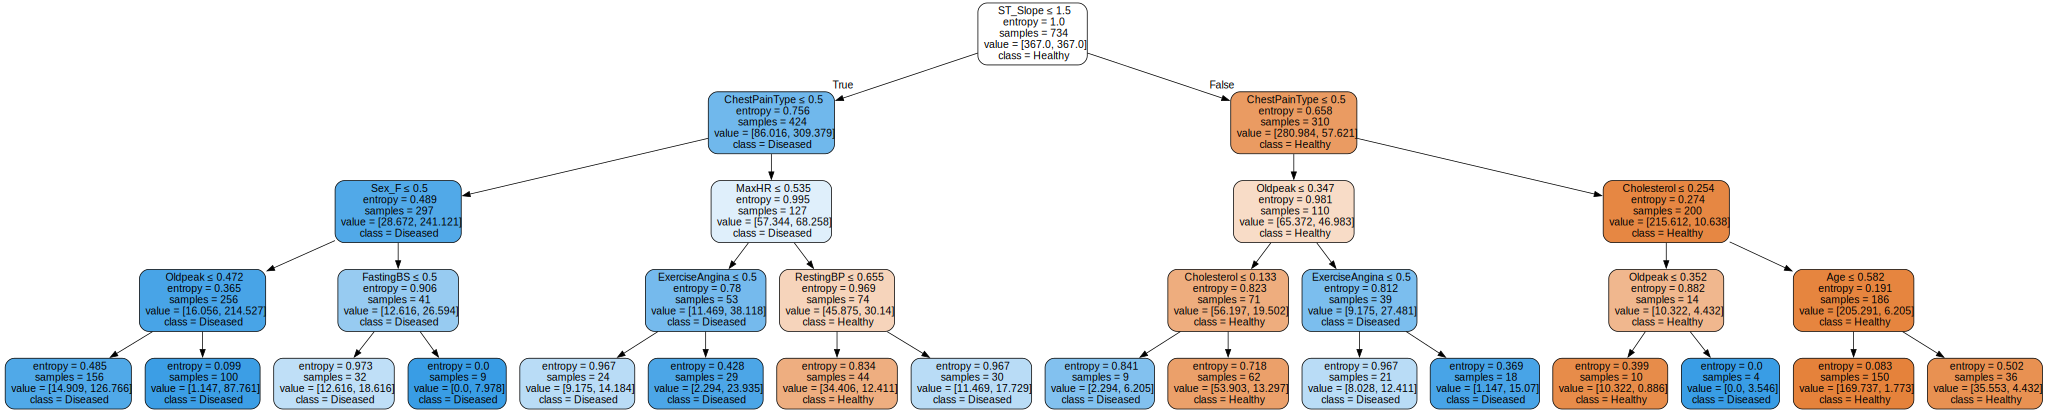

In [24]:
# Needs Graphviz *system* tools on PATH (not only: pip install graphviz).
# macOS: brew install graphviz   then restart the notebook kernel.
import graphviz

dot_data = tree.export_graphviz(tree_model_balanced, out_file=None,
                     feature_names=X_train_enc.columns,
                     class_names=['Healthy', 'Diseased'],
                     filled=True, rounded=True,
                   special_characters=True)
graph = graphviz.Source(dot_data)
graph  # display in the notebook (calls `dot` under the hood)



In [19]:
# Save PDF next to the notebook (returns path string, e.g. 'tree1.pdf')
tree1_path = graph.render("tree1", format="pdf")
print(tree1_path)

tree1.pdf


 You can also automatically download the created file

In [20]:
# You can also download the file for better visualization
#from google.colab import files
#files.download("tree1.pdf")

Get the most important features. Add them in an array in descending order of importance and create a relevant plot with the feature importance. Useful: feature_importances_, feature_names_in_ (check out [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) attributes for more details), [argsort](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)

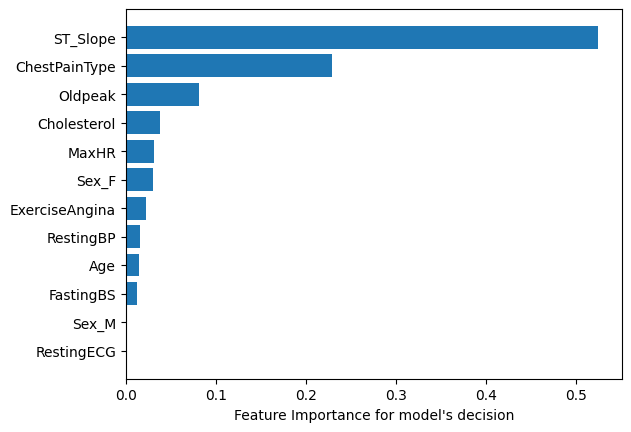

In [25]:
# Sort the feature in descending order of importance
sorted_idx = tree_model_balanced.feature_importances_.argsort()
# Create the plot
plt.barh(tree_model_balanced.feature_names_in_[sorted_idx], tree_model_balanced.feature_importances_[sorted_idx])
plt.xlabel("Feature Importance for model's decision");